# Career Path Transformer — Run Comparison

Head-to-head comparison of the two MLflow runs the demo is wired to
(experiment **51**, partner **sj**, trained on the same held-out eval set):

| arch | run id | run name | logged model |
|---|---|---|---|
| **item2vec** | `3e215487579b42e395a25d75b57ad731` | `sassy-asp-235` | `m-5f4cf760411442aa896bd33b756e17db` |
| **bert4rec** | `6dde1506e8434550a9bb21a92a3aef1d` | `nosy-carp-957` | `m-23e2f2300a274a0c98ab6ef896448dd1` |

Both predict the **next job title** given a candidate's career history (work +
education tokens). Metrics are computed over the same held-out test set
(~44.6k context→target pairs). This notebook pulls the logged metrics straight
from MLflow and cross-checks them against the per-run predictions CSVs.

> Run with the **`dwh-ai-py311`** conda env. MLflow connection details are read
> from `datawarehouse-configurations/sj/ai/ai.conf` (`test-prod-sj.mlflow.*`),
> the same source the inference notebook uses.

In [ ]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyhocon import ConfigFactory

CONF = '../../datawarehouse-configurations/sj/ai/ai.conf'   # relative to this notebook
conf = ConfigFactory.parse_file(os.path.abspath(CONF))
mlflow.set_tracking_uri(conf.get_string('test-prod-sj.mlflow.mlflow_url'))
os.environ['MLFLOW_TRACKING_USERNAME'] = conf.get_string('test-prod-sj.mlflow.mlflow_user')
os.environ['MLFLOW_TRACKING_PASSWORD'] = conf.get_string('test-prod-sj.mlflow.mlflow_password')

client = mlflow.MlflowClient()
RUNS = {
    'item2vec': '3e215487579b42e395a25d75b57ad731',   # sassy-asp-235
    'bert4rec': '6dde1506e8434550a9bb21a92a3aef1d',   # nosy-carp-957
}
runs = {name: client.get_run(rid) for name, rid in RUNS.items()}
metrics = {name: r.data.metrics for name, r in runs.items()}
params  = {name: r.data.params  for name, r in runs.items()}
print('connected:', conf.get_string('test-prod-sj.mlflow.mlflow_url'))
for name, r in runs.items():
    print(f'  {name:9s} {RUNS[name]}  ({r.data.tags.get("mlflow.runName")})  status={r.info.status}')

/opt/homebrew/Caskroom/miniforge/base/envs/dwh-ai-py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


connected: https://mlflow-tracking.dwh.shared-dev.swipejobs-exchange.com
  item2vec  3e215487579b42e395a25d75b57ad731  (sassy-asp-235)  status=FINISHED
  bert4rec  6dde1506e8434550a9bb21a92a3aef1d  (nosy-carp-957)  status=FINISHED


## 1. Headline test metrics

Recall@k = share of pairs where the true next title is in the model's top-k;
MRR = mean reciprocal rank of the true title (full ranking). Higher is better.

In [2]:
def col(name, keys):
    return [metrics[name].get(k) for k in keys]

head_keys = ['test_recall_at_1', 'test_recall_at_5', 'test_recall_at_10', 'test_mrr']
head = pd.DataFrame({
    'item2vec': col('item2vec', head_keys),
    'bert4rec': col('bert4rec', head_keys),
}, index=['Recall@1', 'Recall@5', 'Recall@10', 'MRR'])
head['winner']   = np.where(head['item2vec'] >= head['bert4rec'], 'item2vec', 'bert4rec')
head['abs_gain'] = (head['item2vec'] - head['bert4rec']).abs()
head['rel_gain'] = head['abs_gain'] / head[['item2vec','bert4rec']].min(axis=1)
disp = head.copy()
for c in ['item2vec','bert4rec','abs_gain']:
    disp[c] = disp[c].map(lambda x: f'{x:.4f}')
disp['rel_gain'] = head['rel_gain'].map(lambda x: f'+{x*100:.0f}%')
disp

,item2vec,bert4rec,winner,abs_gain,rel_gain
Recall@1,0.1817,0.1059,item2vec,0.0757,+72%
Recall@5,0.3351,0.2418,item2vec,0.0933,+39%
Recall@10,0.4070,0.3309,item2vec,0.0762,+23%
MRR,0.2594,0.1797,item2vec,0.0797,+44%


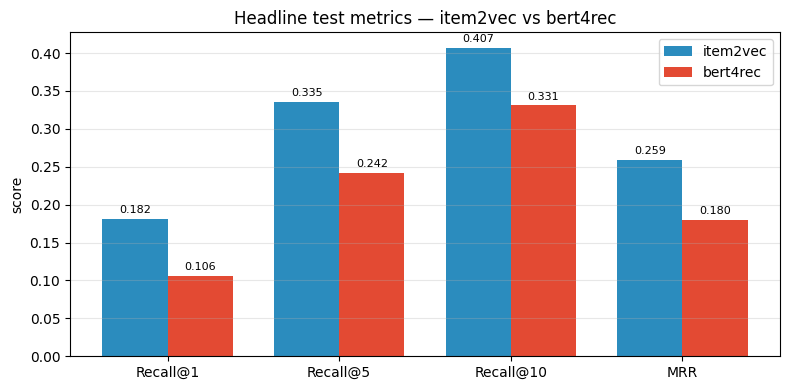

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(head)); w = 0.38
ax.bar(x - w/2, head['item2vec'], w, label='item2vec', color='#2b8cbe')
ax.bar(x + w/2, head['bert4rec'], w, label='bert4rec', color='#e34a33')
ax.set_xticks(x); ax.set_xticklabels(head.index)
ax.set_title('Headline test metrics — item2vec vs bert4rec')
ax.set_ylabel('score'); ax.legend(); ax.grid(axis='y', alpha=0.3)
for i, (a, b) in enumerate(zip(head['item2vec'], head['bert4rec'])):
    ax.text(i - w/2, a + .005, f'{a:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + w/2, b + .005, f'{b:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

## 2. By candidate segment

`mixed` = history has both work and education; `work_only` / `education_only`
as named. Education-only is the cold-start case (we only know what they studied).

In [4]:
segs = ['mixed', 'work_only', 'education_only']
seg = pd.DataFrame({
    'item2vec R@10': [metrics['item2vec'][f'test_{s}_recall_at_10'] for s in segs],
    'bert4rec R@10': [metrics['bert4rec'][f'test_{s}_recall_at_10'] for s in segs],
    'item2vec MRR':  [metrics['item2vec'][f'test_{s}_mrr'] for s in segs],
    'bert4rec MRR':  [metrics['bert4rec'][f'test_{s}_mrr'] for s in segs],
    'n':             [int(metrics['item2vec'][f'test_{s}_n']) for s in segs],
}, index=segs)
seg.round(4)

,item2vec R@10,bert4rec R@10,item2vec MRR,bert4rec MRR,n
mixed,0.4262,0.3455,0.2712,0.1875,32162
work_only,0.4242,0.3488,0.2784,0.1949,9112
education_only,0.1762,0.1411,0.0931,0.0631,3338


## 3. By context length

How many history tokens the model has seen. Both models improve with more
context; the gap between them is what matters here.

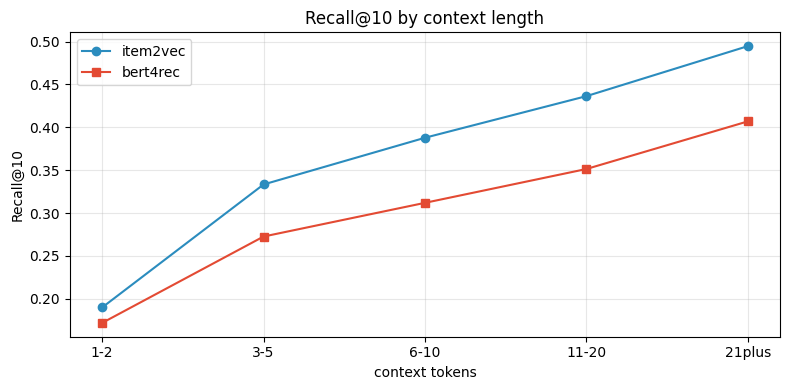

,item2vec R@10,bert4rec R@10,n,gap (pp)
1-2,0.1900,0.1720,2063,1.8018
3-5,0.3334,0.2727,7114,6.0725
6-10,0.3879,0.3120,11622,7.5891
11-20,0.4364,0.3514,15323,8.4970
21plus,0.4947,0.4069,8490,8.7750


In [5]:
cls = ['1-2', '3-5', '6-10', '11-20', '21plus']
ctx = pd.DataFrame({
    'item2vec R@10': [metrics['item2vec'][f'test_ctxlen_{c}_recall_at_10'] for c in cls],
    'bert4rec R@10': [metrics['bert4rec'][f'test_ctxlen_{c}_recall_at_10'] for c in cls],
    'n':             [int(metrics['item2vec'][f'test_ctxlen_{c}_n']) for c in cls],
}, index=cls)
ctx['gap (pp)'] = (ctx['item2vec R@10'] - ctx['bert4rec R@10']) * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cls, ctx['item2vec R@10'], 'o-', label='item2vec', color='#2b8cbe')
ax.plot(cls, ctx['bert4rec R@10'], 's-', label='bert4rec', color='#e34a33')
ax.set_title('Recall@10 by context length'); ax.set_xlabel('context tokens')
ax.set_ylabel('Recall@10'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
ctx.round(4)

## 4. Hyperparameters & training facts

What differs between the two runs (beyond architecture). Shared eval set, same
title vocab (14,341 `W_TITLE` tokens), same `d_model`/`vector_size` = 128.

In [6]:
keys = sorted(set(params['item2vec']) | set(params['bert4rec']))
pdiff = pd.DataFrame({
    'item2vec': [params['item2vec'].get(k, '—') for k in keys],
    'bert4rec': [params['bert4rec'].get(k, '—') for k in keys],
}, index=keys)
pdiff['differs'] = pdiff['item2vec'] != pdiff['bert4rec']
facts = pd.DataFrame({
    'item2vec': [int(metrics['item2vec'][k]) for k in ['vocab_size','vocab_w_title','test_eval_n']],
    'bert4rec': [int(metrics['bert4rec'][k]) for k in ['vocab_size','vocab_w_title','test_eval_n']],
}, index=['vocab_size','title_tokens (W_TITLE)','eval_pairs'])
print('Training facts:'); display(facts)
print('\nParameters (differing rows only):')
pdiff[pdiff['differs']]

Training facts:


,item2vec,bert4rec
vocab_size,15207,15209
title_tokens (W_TITLE),14341,14341
eval_pairs,44612,44613



Parameters (differing rows only):


,item2vec,bert4rec,differs
architecture,item2vec,bert4rec,True
batch_size,—,256,True
center_titles,False,—,True
d_model,—,128,True
dropout,—,0.2,True
finetune_all_positions,—,False,True
finetune_epochs,—,0,True
finetune_lr,—,1e-05,True
finetune_patience,—,3,True
finetune_target,—,all,True


## 5. Cross-check against the predictions CSVs

The logged metrics should be reproducible from each run's `top_10_predictions`
column. Recall@k matches exactly; the recomputed MRR is slightly lower than the
logged MRR because it is truncated at top-10 (titles ranked >10 score 0), while
the logged MRR uses the full ranking.

In [7]:
CSV = {
    'item2vec': '../incoming/career_path_transformer_20260618_222849.csv',
    'bert4rec': '../incoming/career_path_transformer_20260618_223046.csv',
}
rows = []
for name, path in CSV.items():
    df = pd.read_csv(path)
    preds = (df['top_10_predictions'].str.split(' | ', regex=False)
             .apply(lambda L: [p.rsplit(' (', 1)[0] for p in L]))
    tgt = df['correct_target']
    rank = [(P.index(t) + 1) if t in P else None for t, P in zip(tgt, preds)]
    rows.append({
        'model': name, 'n': len(df),
        'R@1':  np.mean([r == 1 for r in rank]),
        'R@5':  np.mean([r is not None and r <= 5 for r in rank]),
        'R@10': np.mean([r is not None for r in rank]),
        'MRR@10 (recomputed)': np.mean([1.0 / r if r else 0.0 for r in rank]),
        'MRR (logged, full rank)': metrics[name]['test_mrr'],
    })
pd.DataFrame(rows).set_index('model').round(4)

,n,R@1,R@5,R@10,MRR@10 (recomputed),"MRR (logged, full rank)"
model,,,,,,
item2vec,44612,0.1817,0.3351,0.4070,0.2479,0.2594
bert4rec,44613,0.1059,0.2418,0.3309,0.1655,0.1797


## Summary

**item2vec (`sassy-asp-235`) clearly outperforms bert4rec (`nosy-carp-957`)** on
this eval set, on every metric and every slice:

- **Recall@10 40.7% vs 33.1%** (+7.6pp), **Recall@1 18.2% vs 10.6%** (+7.6pp,
  ~70% relative), **MRR 0.259 vs 0.180** (+44% relative).
- The win holds across **all segments** — `mixed` (+8.1pp R@10), `work_only`
  (+7.5pp), `education_only` (+3.5pp, both weak in this cold-start case).
- The win holds across **all context lengths**, and the gap *widens* with more
  history (+1.8pp at 1–2 tokens → +8.8pp at 21+).
- Same eval set (~44.6k pairs), same 14,341-title vocab, same 128-dim embeddings
  — so this is a fair architecture/training comparison, not a data artefact.

**Takeaway:** the simple item2vec (skip-gram, window 16, last-8-context mean)
beats the BERT4Rec transformer here. BERT4Rec's softmax over titles is also very
flat (top probabilities ~0.05–0.13), i.e. it's genuinely uncertain. The demo
keeps both so the difference is visible side by side, but item2vec is the
stronger model on these runs.

*(Caveat: these are next-title ranking metrics over the SJ title set. They don't
capture embedding-space quality or the Sankey transition view, which the demo
also surfaces.)*